In [ ]:
import pickle
from pathlib import Path
from msd_with_com import fit_diffusion, a2ps_to_m2s
from matplotlib import pyplot as plt
import numpy as np

: 

In [36]:
min_fit_ps = 1000
max_fit_ps_list = np.linspace(2000,20000,10)
def fit_diffusion_wrapper(tau, msd_cat, msd_anion, msd_solvent, TAU_MIN_FIT_PS, TAU_MAX_FIT_PS):
    Dcat_a2ps, slope_c, b_c, mask_c = fit_diffusion(tau, msd_cat, TAU_MIN_FIT_PS, TAU_MAX_FIT_PS)
    Dcat_1e10 = a2ps_to_m2s(Dcat_a2ps) * 1e10
    print(f"   → D(Na⁺) = {Dcat_1e10:.2f} ×10⁻¹⁰ m²/s ({Dcat_a2ps:.4f} Å²/ps)")


    Danion_a2ps, slope_a, b_a, mask_a = fit_diffusion(tau, msd_anion, TAU_MIN_FIT_PS, TAU_MAX_FIT_PS)
    Danion_1e10 = a2ps_to_m2s(Danion_a2ps) * 1e10
    print(f"   → D(anion) = {Danion_1e10:.2f} ×10⁻¹⁰ m²/s ({Danion_a2ps:.4f} Å²/ps)")


    Dsolv_a2ps, slope_s, b_s, mask_s = fit_diffusion(tau, msd_solvent, TAU_MIN_FIT_PS, TAU_MAX_FIT_PS)
    Dsolv_1e10 = a2ps_to_m2s(Dsolv_a2ps) * 1e10
    print(f"   → D(solvent) = {Dsolv_1e10:.2f} ×10⁻¹⁰ m²/s ({Dsolv_a2ps:.4f} Å²/ps)")

    return Dcat_1e10, Danion_1e10, Dsolv_1e10, Dcat_a2ps, Danion_a2ps, Dsolv_a2ps

In [37]:
# Paths to the msd_dict files
msd_dict_path_naotf = Path("/global/homes/y/yuejian/project/MLFF-distill/yuejian/electrolyte_application/ablate_distillation/observables/msd/convergence_analysis/two_systems_slurm/12000ps/msd_dict_NaOTf — DME.pkl")
msd_dict_path_napf6 = Path("/global/homes/y/yuejian/project/MLFF-distill/yuejian/electrolyte_application/ablate_distillation/observables/msd/convergence_analysis/two_systems_slurm/12000ps/msd_dict_NaPF6 — DME.pkl")

# Load the msd_dict files using pickle
with open(msd_dict_path_naotf, "rb") as f:
    msd_dict_naotf = pickle.load(f)

with open(msd_dict_path_napf6, "rb") as f:
    msd_dict_napf6 = pickle.load(f)

# You can now inspect msd_dicts, for example:
print("NaOTf — DME dict keys:", msd_dict_naotf.keys())
print("NaPF6 — DME dict keys:", msd_dict_napf6.keys())
# Unpack variables from msd_dict_naotf
tau_naotf         = msd_dict_naotf["tau"]
msd_cat_naotf     = msd_dict_naotf["msd_cat"]
msd_anion_naotf   = msd_dict_naotf["msd_anion"]
msd_solvent_naotf = msd_dict_naotf["msd_solvent"]
dt_ps_naotf       = msd_dict_naotf["dt_ps"]
eq_time_ps_naotf  = msd_dict_naotf["EQ_TIME_PS"]

# Unpack variables from msd_dict_napf6
tau_napf6         = msd_dict_napf6["tau"]
msd_cat_napf6     = msd_dict_napf6["msd_cat"]
msd_anion_napf6   = msd_dict_napf6["msd_anion"]
msd_solvent_napf6 = msd_dict_napf6["msd_solvent"]
dt_ps_napf6       = msd_dict_napf6["dt_ps"]
eq_time_ps_napf6  = msd_dict_napf6["EQ_TIME_PS"]


NaOTf — DME dict keys: dict_keys(['msd_cat', 'msd_anion', 'msd_solvent', 'tau', 'dt_ps', 'EQ_TIME_PS'])
NaPF6 — DME dict keys: dict_keys(['msd_cat', 'msd_anion', 'msd_solvent', 'tau', 'dt_ps', 'EQ_TIME_PS'])


   → D(Na⁺) = 6.50 ×10⁻¹⁰ m²/s (0.0650 Å²/ps)
   → D(anion) = 8.05 ×10⁻¹⁰ m²/s (0.0805 Å²/ps)
   → D(solvent) = 19.91 ×10⁻¹⁰ m²/s (0.1991 Å²/ps)
   → D(Na⁺) = 5.28 ×10⁻¹⁰ m²/s (0.0528 Å²/ps)
   → D(anion) = 7.01 ×10⁻¹⁰ m²/s (0.0701 Å²/ps)
   → D(solvent) = 17.09 ×10⁻¹⁰ m²/s (0.1709 Å²/ps)
   → D(Na⁺) = 5.13 ×10⁻¹⁰ m²/s (0.0513 Å²/ps)
   → D(anion) = 6.84 ×10⁻¹⁰ m²/s (0.0684 Å²/ps)
   → D(solvent) = 16.10 ×10⁻¹⁰ m²/s (0.1610 Å²/ps)
   → D(Na⁺) = 4.43 ×10⁻¹⁰ m²/s (0.0443 Å²/ps)
   → D(anion) = 5.97 ×10⁻¹⁰ m²/s (0.0597 Å²/ps)
   → D(solvent) = 13.40 ×10⁻¹⁰ m²/s (0.1340 Å²/ps)
   → D(Na⁺) = 4.19 ×10⁻¹⁰ m²/s (0.0419 Å²/ps)
   → D(anion) = 5.44 ×10⁻¹⁰ m²/s (0.0544 Å²/ps)
   → D(solvent) = 11.84 ×10⁻¹⁰ m²/s (0.1184 Å²/ps)
   → D(Na⁺) = 4.36 ×10⁻¹⁰ m²/s (0.0436 Å²/ps)
   → D(anion) = 5.43 ×10⁻¹⁰ m²/s (0.0543 Å²/ps)
   → D(solvent) = 12.18 ×10⁻¹⁰ m²/s (0.1218 Å²/ps)
   → D(Na⁺) = 4.33 ×10⁻¹⁰ m²/s (0.0433 Å²/ps)
   → D(anion) = 5.33 ×10⁻¹⁰ m²/s (0.0533 Å²/ps)
   → D(solvent) = 12.75 ×10⁻¹⁰ m²/s 

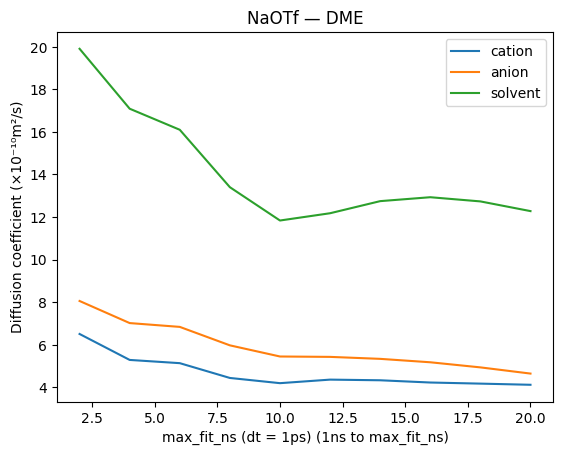

In [38]:
# naotf
D_cations = []
D_anions = []
D_solvent = []

for max_fit_ps in max_fit_ps_list:
    Dcat_1e10, Danion_1e10, Dsolv_1e10, Dcat_a2ps, Danion_a2ps, Dsolv_a2ps = fit_diffusion_wrapper(tau_naotf, msd_cat_naotf, msd_anion_naotf, msd_solvent_naotf, min_fit_ps, max_fit_ps)
    D_cations.append(Dcat_1e10)
    D_anions.append(Danion_1e10)
    D_solvent.append(Dsolv_1e10)

max_fit_ps_list_ns = max_fit_ps_list / 1000

plt.plot(max_fit_ps_list_ns, D_cations,label="cation")
plt.plot(max_fit_ps_list_ns, D_anions,label="anion")
plt.plot(max_fit_ps_list_ns, D_solvent,label="solvent")
plt.legend()
plt.xlabel("max_fit_ns (dt = 1ps) (1ns to max_fit_ns)")
plt.ylabel("Diffusion coefficient (×10⁻¹⁰m²/s)")
plt.title("NaOTf — DME")
plt.show()


   → D(Na⁺) = 3.46 ×10⁻¹⁰ m²/s (0.0346 Å²/ps)
   → D(anion) = 4.21 ×10⁻¹⁰ m²/s (0.0421 Å²/ps)
   → D(solvent) = 7.29 ×10⁻¹⁰ m²/s (0.0729 Å²/ps)
   → D(Na⁺) = 3.61 ×10⁻¹⁰ m²/s (0.0361 Å²/ps)
   → D(anion) = 4.28 ×10⁻¹⁰ m²/s (0.0428 Å²/ps)
   → D(solvent) = 7.48 ×10⁻¹⁰ m²/s (0.0748 Å²/ps)
   → D(Na⁺) = 4.06 ×10⁻¹⁰ m²/s (0.0406 Å²/ps)
   → D(anion) = 4.77 ×10⁻¹⁰ m²/s (0.0477 Å²/ps)
   → D(solvent) = 8.05 ×10⁻¹⁰ m²/s (0.0805 Å²/ps)
   → D(Na⁺) = 4.24 ×10⁻¹⁰ m²/s (0.0424 Å²/ps)
   → D(anion) = 4.83 ×10⁻¹⁰ m²/s (0.0483 Å²/ps)
   → D(solvent) = 8.13 ×10⁻¹⁰ m²/s (0.0813 Å²/ps)
   → D(Na⁺) = 4.49 ×10⁻¹⁰ m²/s (0.0449 Å²/ps)
   → D(anion) = 4.78 ×10⁻¹⁰ m²/s (0.0478 Å²/ps)
   → D(solvent) = 8.37 ×10⁻¹⁰ m²/s (0.0837 Å²/ps)
   → D(Na⁺) = 4.83 ×10⁻¹⁰ m²/s (0.0483 Å²/ps)
   → D(anion) = 4.85 ×10⁻¹⁰ m²/s (0.0485 Å²/ps)
   → D(solvent) = 8.87 ×10⁻¹⁰ m²/s (0.0887 Å²/ps)
   → D(Na⁺) = 5.08 ×10⁻¹⁰ m²/s (0.0508 Å²/ps)
   → D(anion) = 5.06 ×10⁻¹⁰ m²/s (0.0506 Å²/ps)
   → D(solvent) = 9.16 ×10⁻¹⁰ m²/s (0.0916

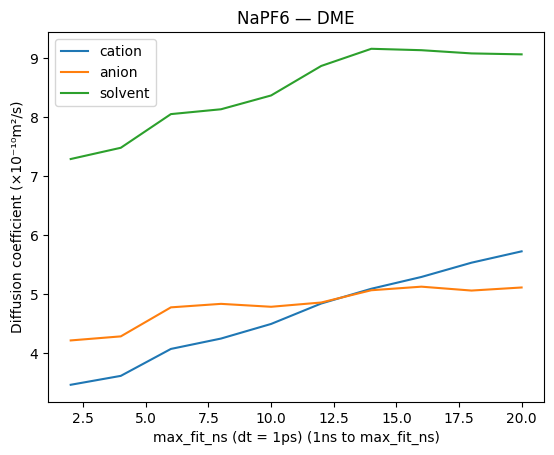

In [39]:
# napf6
D_cations = []
D_anions = []
D_solvent = []

for max_fit_ps in max_fit_ps_list:
    Dcat_1e10, Danion_1e10, Dsolv_1e10, Dcat_a2ps, Danion_a2ps, Dsolv_a2ps = fit_diffusion_wrapper(tau_napf6, msd_cat_napf6, msd_anion_napf6, msd_solvent_napf6, min_fit_ps, max_fit_ps)
    D_cations.append(Dcat_1e10)
    D_anions.append(Danion_1e10)
    D_solvent.append(Dsolv_1e10)

max_fit_ps_list_ns = max_fit_ps_list / 1000

plt.plot(max_fit_ps_list_ns, D_cations,label="cation")
plt.plot(max_fit_ps_list_ns, D_anions,label="anion")
plt.plot(max_fit_ps_list_ns, D_solvent,label="solvent")
plt.legend()
plt.xlabel("max_fit_ns (dt = 1ps) (1ns to max_fit_ns)")
plt.ylabel("Diffusion coefficient (×10⁻¹⁰m²/s)")
plt.title("NaPF6 — DME")
plt.show()
